# 🔆 Overview

This notebook generates 2 sets of datasets:
* one full data that has both test and train set (all_cv_df.csv)
* one set with separate test and train set (cv_train_df.csv / cv_test_df.csv)


In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/all_data'

if os.path.exists(dataset_path):
    print(f"Files in '{dataset_path}':")
    found_files = [f for f in os.listdir(dataset_path) if f.endswith("csv")]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/all_data':
TalkFile_버찌버찌_glucose_canine1.csv
TalkFile_사랑이김_glucose_canine3.csv
TalkFile_빵진_glucose_canine2.csv
TalkFile_연주송_glucose_canine4.csv
TalkFile_지혜김_glucose_canine5.csv


In [4]:
file1 = os.path.join(dataset_path, found_files[2])
file1_pd = pd.read_csv(file1)
display(file1_pd.head(2))

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
0,FreeStyle LibreLink,596075b8-e37a-4e67-a46f-cc5b667465ab,4/5/25 20:40,6,NaN,NaN
1,FreeStyle LibreLink,596075b8-e37a-4e67-a46f-cc5b667465ab,4/9/25 18:21,6,NaN,NaN


In [5]:
dfs = []


for filename in found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path)

    # Add a new column 'ID' (changed name from file_identifier)
    df['ID'] = identifier

    # Address timestamp format
    df["Device Timestamp"] = pd.to_datetime(df['Device Timestamp'], format='%m/%d/%y %H:%M')


    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df1 = pd.concat(dfs, ignore_index=True)

display(combined_df1.head())

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL,ID
0,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,2025-12-02 11:50:00,0,260.0,NaN,canine1
1,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,2025-12-02 12:05:00,0,281.0,NaN,canine1
2,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,2025-12-02 12:20:00,0,296.0,NaN,canine1
3,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,2025-12-02 12:35:00,0,287.0,NaN,canine1
4,FreeStyle LibreLink,a2e73825-5603-4370-9edc-6941970d3b10,2025-12-02 12:50:00,0,285.0,NaN,canine1


In [6]:
dataset_path = '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/all_data/updated_data'

if os.path.exists(dataset_path):
    print(f"Files in '{dataset_path}':")
    found_files = [f for f in os.listdir(dataset_path) if f.endswith("csv")]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/all_data/updated_data':
TalkFile_사랑양_glucose_canine3.csv.csv
TalkFile_현수김_glucose_canine6.csv.csv


In [7]:

dfs = []


for filename in found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path, header = 2, usecols = [0, 1, 2, 3, 4, 5])

    # Add a new column 'ID' (changed name from file_identifier)
    df['ID'] = identifier

    # timestamp already matches the format
    df["Device Timestamp"] = pd.to_datetime(df['Device Timestamp'])

    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df2 = pd.concat(dfs, ignore_index=True)

display(combined_df2.head())

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL,ID
0,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:11:00,0,364.0,NaN,canine3
1,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:26:00,0,288.0,NaN,canine3
2,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:41:00,0,223.0,NaN,canine3
3,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:56:00,0,181.0,NaN,canine3
4,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 21:10:00,0,162.0,NaN,canine3


In [8]:
combined_df = pd.concat((combined_df1, combined_df2))
# sort by ID
combined_df = combined_df.sort_values(by = ["ID", "Device Timestamp"])

print(f"Shape of the combined DataFrame: {combined_df.shape}")
# printing everything because we only have 6 rows
print("Combined DataFrame:")
display(combined_df.groupby("ID").head(2))

Shape of the combined DataFrame: (42715, 7)
Combined DataFrame:


,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL,ID
3281,FreeStyle LibreLink,90368fa5-f3e6-47f7-82bd-ced2486bb95b,2025-10-31 18:28:00,6,NaN,NaN,canine1
2251,FreeStyle LibreLink,90368fa5-f3e6-47f7-82bd-ced2486bb95b,2025-11-01 05:51:00,0,375.0,NaN,canine1
12335,FreeStyle LibreLink,BA237357-D824-4192-B451-396D3D16350C,2025-04-05 20:39:00,6,NaN,NaN,canine2
12298,FreeStyle LibreLink,596075b8-e37a-4e67-a46f-cc5b667465ab,2025-04-05 20:40:00,6,NaN,NaN,canine2
9564,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2025-04-12 18:02:00,6,NaN,NaN,canine3
3591,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2025-04-12 19:03:00,0,500.0,NaN,canine3
15829,FreeStyle LibreLink,3689d896-77d3-4df0-9ac5-55b436d78db5,2025-03-30 12:12:00,6,NaN,NaN,canine4
13359,FreeStyle LibreLink,3689d896-77d3-4df0-9ac5-55b436d78db5,2025-03-30 13:38:00,0,200.0,NaN,canine4
21951,FreeStyle LibreLink,E9A0CE98-AA19-4E58-8F27-31A26580354B,2025-03-22 16:42:00,6,NaN,NaN,canine5
21952,FreeStyle LibreLink,E9A0CE98-AA19-4E58-8F27-31A26580354B,2025-03-22 16:43:00,6,NaN,NaN,canine5


In [9]:
# get observations from record type 0 or 1 (because all other observations are NA for glucose levels)
combined_df = combined_df[combined_df["Record Type"].isin([0, 1])].copy()

# get combined glucose levels
combined_df["glucose"] = combined_df["Historic Glucose mg/dL"].fillna(combined_df["Scan Glucose mg/dL"])

# reformatting timestamp
combined_df["timestamp"] = pd.to_datetime(combined_df["Device Timestamp"])

# sort by ID and timestamp
combined_df = combined_df.sort_values(["ID", "timestamp"])

combined_df = combined_df[["ID", "timestamp", "glucose"]]

# adding glucose category
combined_df["glucose_category"] = np.select(

    # set ranges
    [
        combined_df["glucose"] < 65,
        combined_df["glucose"] > 250
    ],
    # set categories
    [
        "hypoglycemia",
        "hyperglycemia"
    ],
    # other cases
    default = "normal"
)

# now adding normal_ranges
combined_df["normal_range"] = combined_df["glucose_category"] == "normal"


# now check shape, first rows, dtype
print(f"Shape of the combined DataFrame: {combined_df.shape}")
print("Combined DataFrame:")

# displaying first two rows to check for time order
display(combined_df.groupby("ID").head(2))

display(combined_df.dtypes)

Shape of the combined DataFrame: (36455, 5)
Combined DataFrame:


,ID,timestamp,glucose,glucose_category,normal_range
2251,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False
2252,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False
12300,canine2,2025-04-09 12:56:00,308.0,hyperglycemia,False
12301,canine2,2025-04-09 13:11:00,274.0,hyperglycemia,False
3591,canine3,2025-04-12 19:03:00,500.0,hyperglycemia,False
7452,canine3,2025-04-12 19:06:00,500.0,hyperglycemia,False
13359,canine4,2025-03-30 13:38:00,200.0,normal,True
13360,canine4,2025-03-30 13:53:00,177.0,normal,True
20444,canine5,2025-03-22 17:43:00,478.0,hyperglycemia,False
15888,canine5,2025-03-22 17:44:00,469.0,hyperglycemia,False


,0
ID,object
timestamp,datetime64[ns]
glucose,float64
glucose_category,object
normal_range,bool


## Duplicates

Total number of duplicates: 1068
----------------------------------------------------------------------------------------------------------------------------------------------------------------


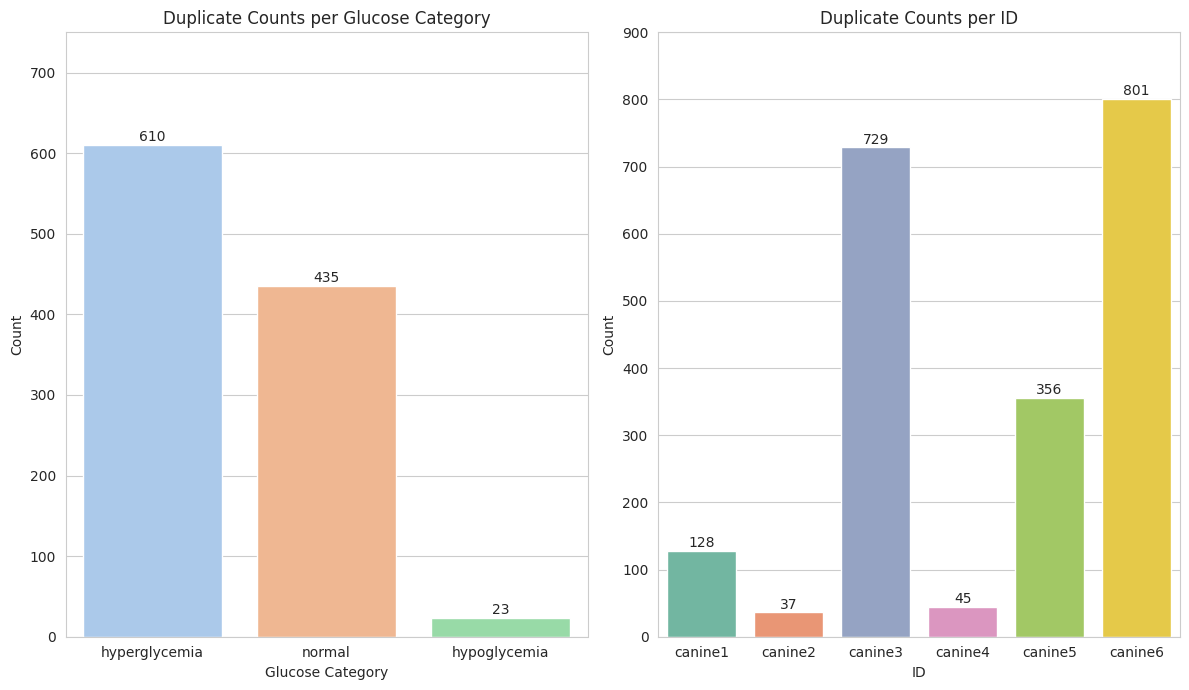

In [10]:
duplicate_counts = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"])]["glucose_category"].value_counts()

duplicate_by_ID = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"], keep = False)].groupby("ID").size()

print(f"Total number of duplicates: {duplicate_counts.sum()}")

print("--"*80)

fig, axes = plt.subplots(1, 2, figsize = (12, 7))

# duplicates by glucose category
ax1 = sns.barplot(
    ax = axes[0],
    data = duplicate_counts.reset_index(name = "count"),
    x = "glucose_category",
    y = "count",
    hue = "glucose_category",
    palette = "pastel"
)

for p in ax1.patches:
  height = p.get_height()
  ax1.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax1.set_title("Duplicate Counts per Glucose Category")
ax1.set_xlabel("Glucose Category")
ax1.set_ylabel("Count")
ax1.set_ylim(0, 750)


ax2 = sns.barplot(
    ax = axes[1],
    data = duplicate_by_ID.reset_index(name = "count"),
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
)

for p in ax2.patches:
  height = p.get_height()
  ax2.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax2.set_title("Duplicate Counts per ID")
ax2.set_xlabel("ID")
ax2.set_ylabel("Count")
ax2.set_ylim(0, 900)

plt.tight_layout()

In [11]:
dup_removed = (
    combined_df
    # sort time and glucose levels
    .sort_values(["ID", "timestamp", "glucose"])

    # get only the first observation such that we are getting the lowest value for glucose level with the same timestamp
    .drop_duplicates(subset = ["ID", "timestamp"], keep = "first")
    .reset_index(drop = True)
)

In [12]:
# check that there are no duplicates now
dup_removed[dup_removed.duplicated(subset = ["ID", "timestamp"])]

,ID,timestamp,glucose,glucose_category,normal_range


### ⭐ Data Visualization after removing duplicates

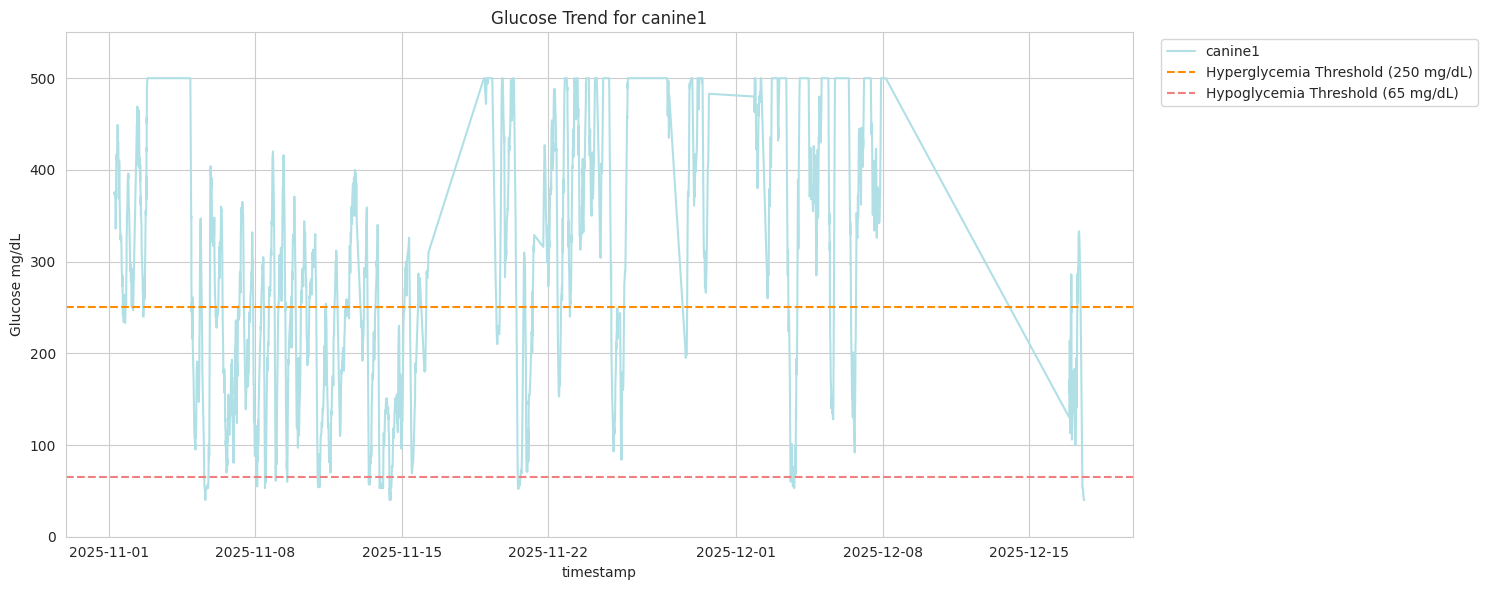

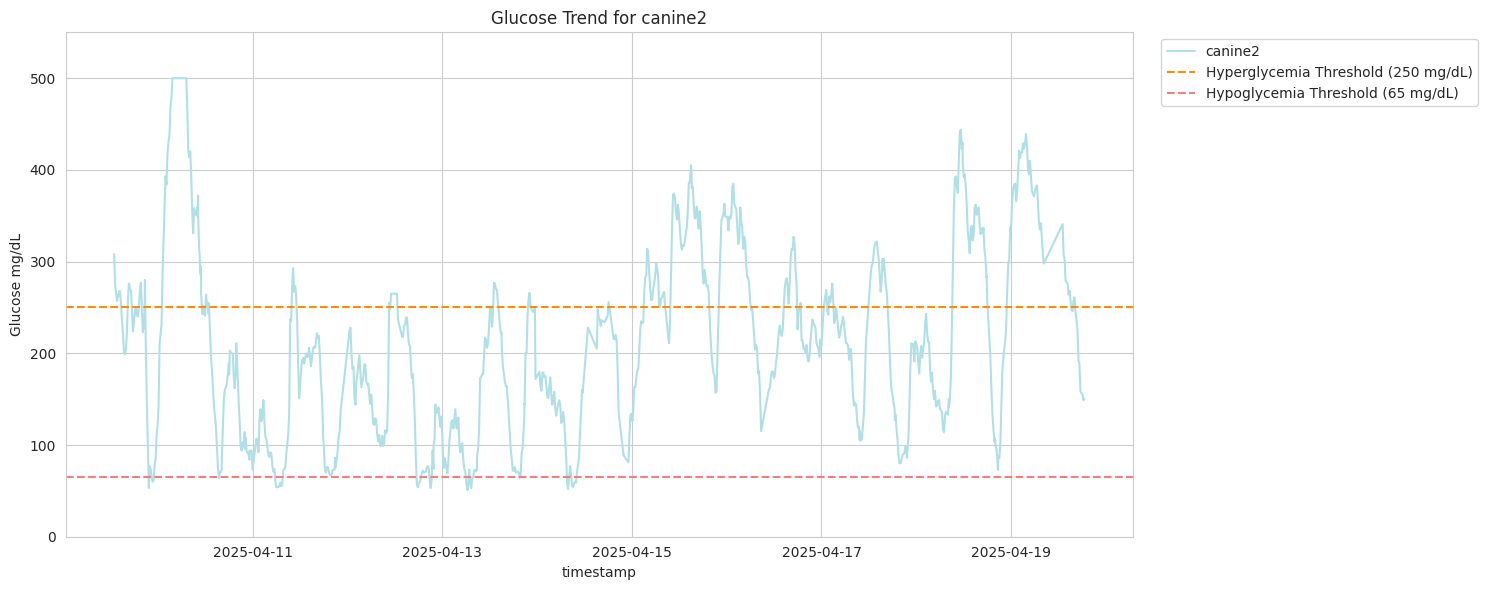

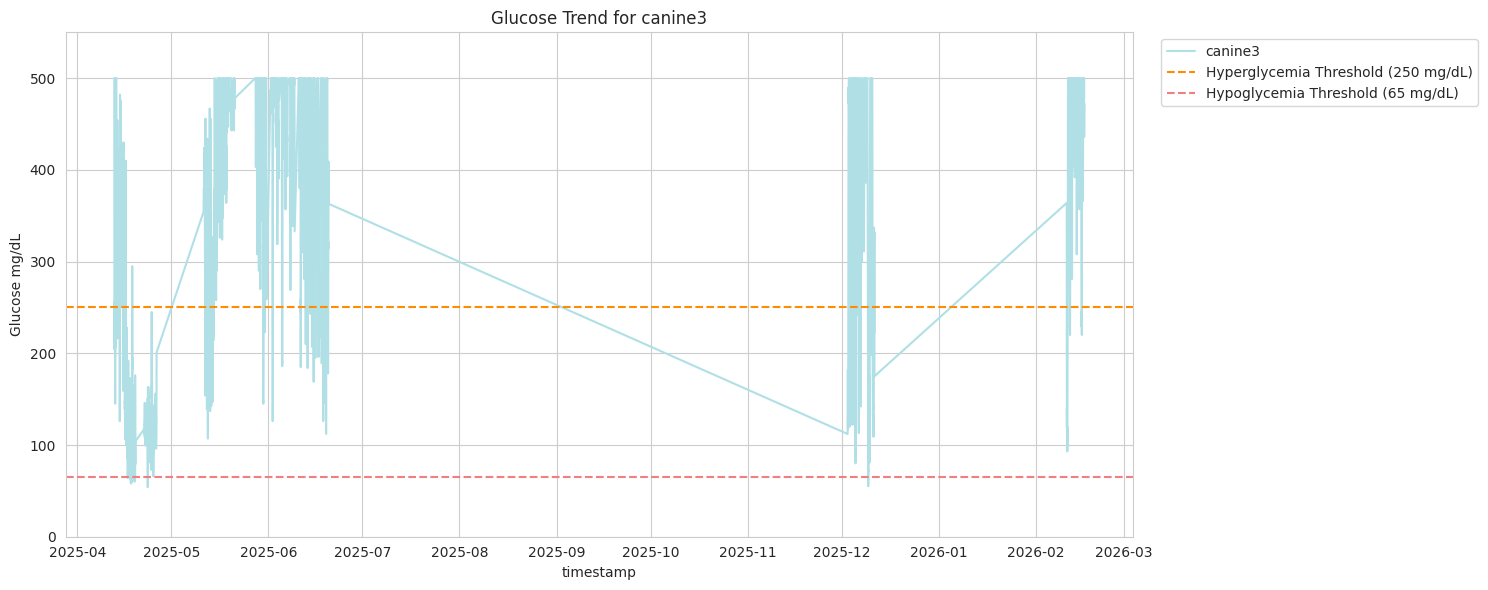

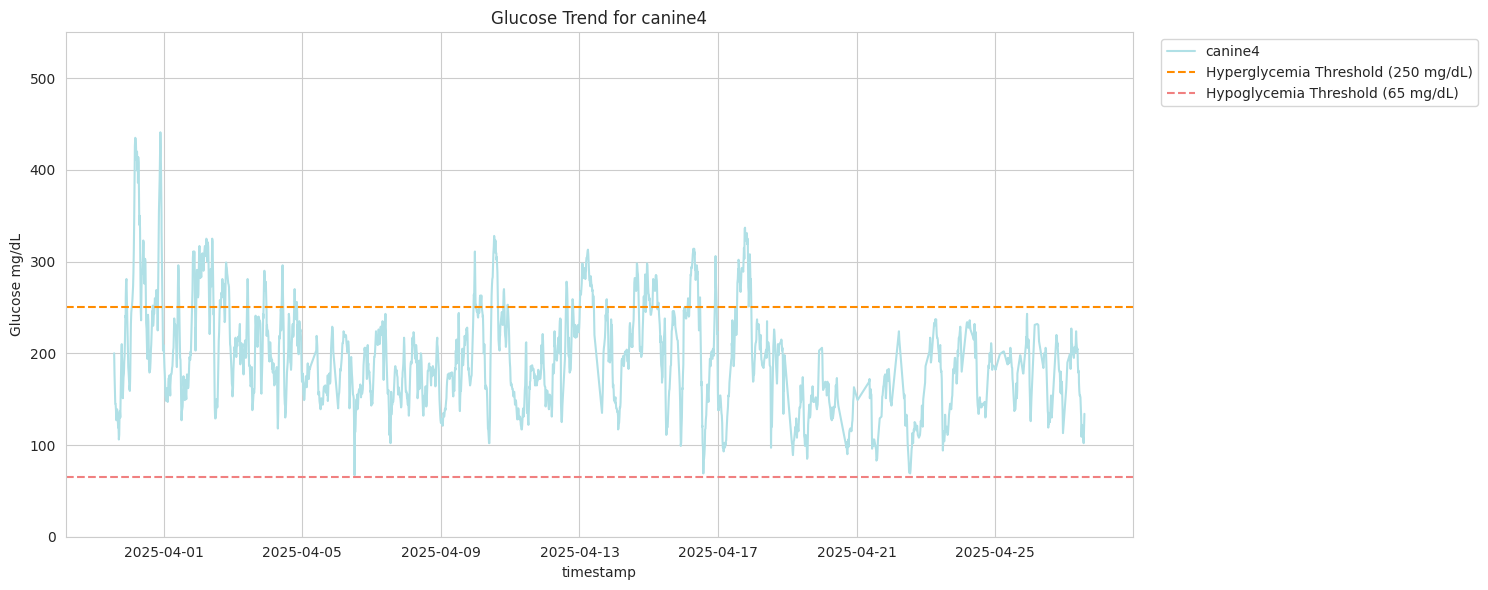

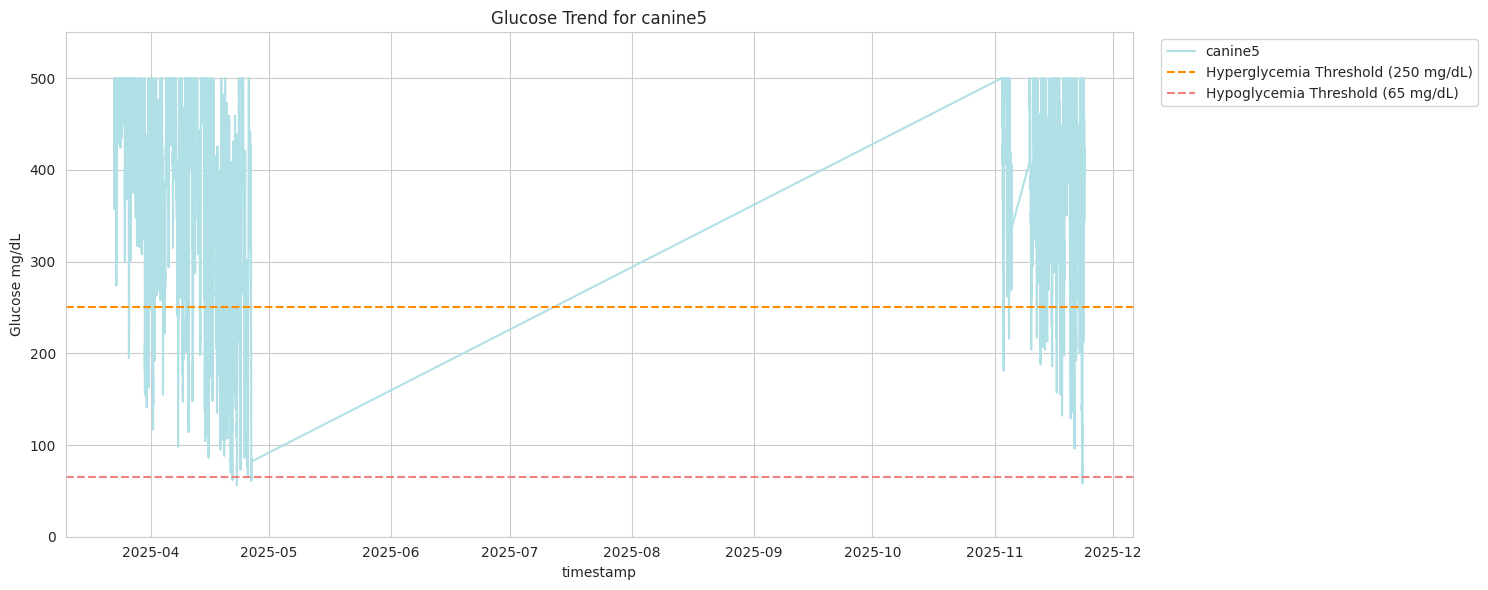

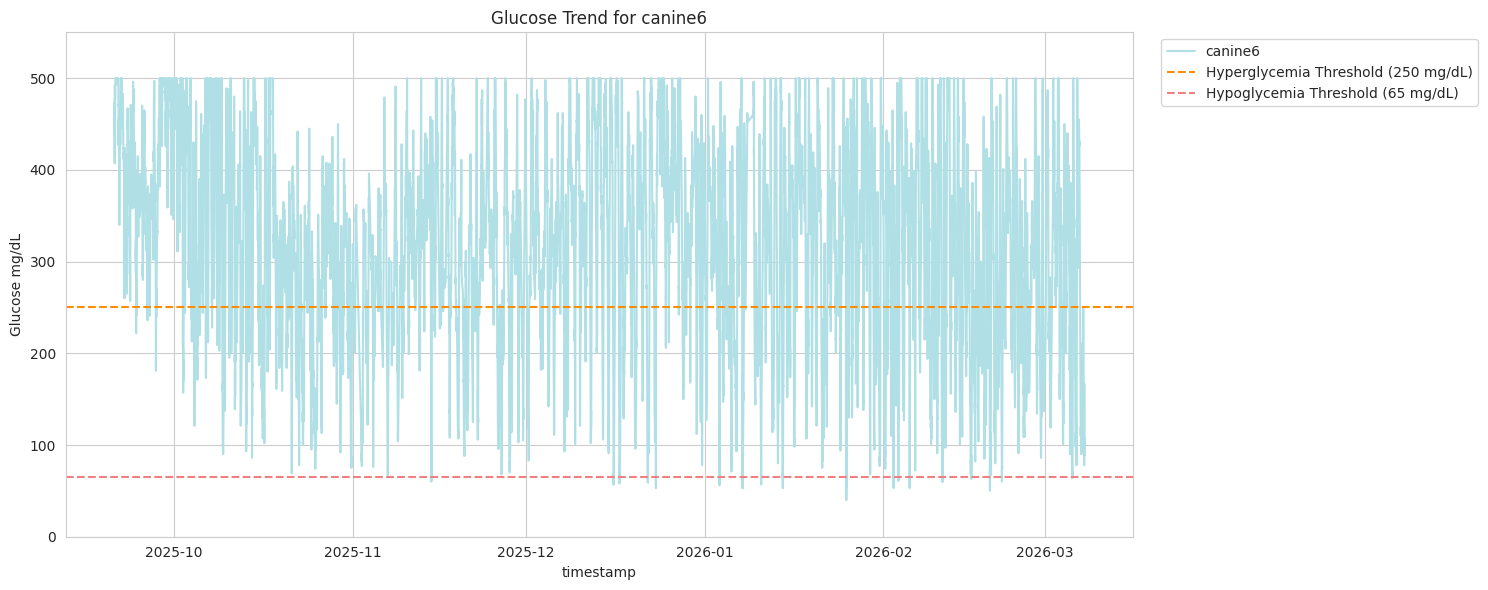

In [13]:
# revised from Ci's code
unique_ids = dup_removed['ID'].unique()

for id in unique_ids:
    plt.figure(figsize=(15, 6))

    # Filter data for the current id
    df_filtered = dup_removed[dup_removed['ID'] == id]

    # Sort by 'timestamp' to ensure chronological order
    df_filtered = df_filtered.sort_values(by='timestamp')

    # Plot glucose trend for the current identifier
    sns.lineplot(data=df_filtered, x='timestamp', y='glucose', label=id, color = "powderblue")

    # Add alarming thresholds for glucose = 250 (Hyperglycemia) first
    plt.axhline(y=250, color='darkorange', linestyle='--', label='Hyperglycemia Threshold (250 mg/dL)')
    # Add alarming thresholds for glucose = 65 (Hypoglycemia) second
    plt.axhline(y=65, color='lightcoral', linestyle='--', label='Hypoglycemia Threshold (65 mg/dL)')


    plt.title(f'Glucose Trend for {id}')
    plt.xlabel('timestamp')
    plt.ylabel('Glucose mg/dL')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='')
    plt.grid(True)
    plt.ylim((0, 550))
    plt.tight_layout()
    plt.show()

In [14]:
gap_df = dup_removed.copy()
gap_df["gap_min"] = (
    gap_df
    .groupby("ID")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

gap_count = gap_df.groupby("ID")["gap_min"].agg(["min", "max", "median", "std", "count"]).reset_index()


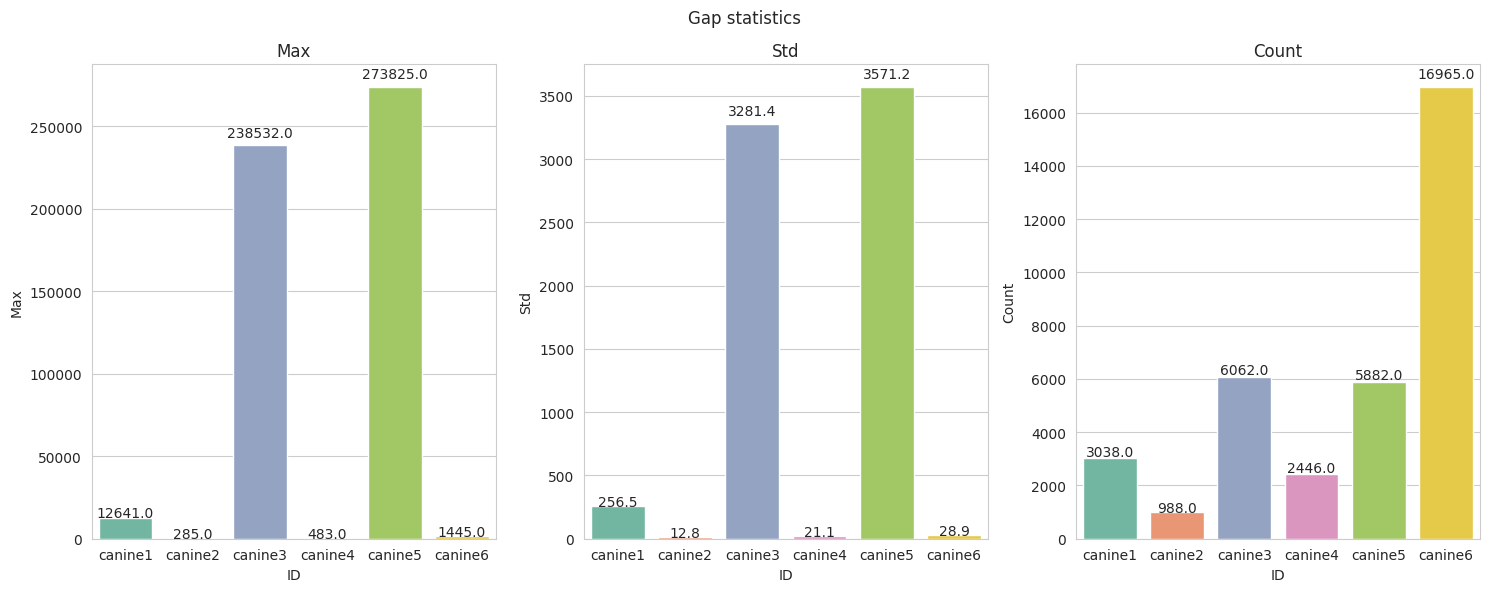

In [15]:
stats = ["max", "std", "count"]

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 6), sharey = False)

axes = axes.flatten()

for ax, stat in zip(axes, stats):
  sns.barplot(
      data = gap_count,
      x = "ID",
      y = stat,
      ax = ax,
      hue = "ID",
      palette = "Set2"
  )
  # labeling
  for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height + (height/50),
      s = f"{height:.1f}",
      ha = "center"
      )

  ax.set_title(stat.capitalize())
  ax.set_xlabel("ID")
  ax.set_ylabel(stat.capitalize())

plt.tight_layout(rect = [0, 0, 1, .95])
plt.suptitle("Gap statistics")
plt.show()


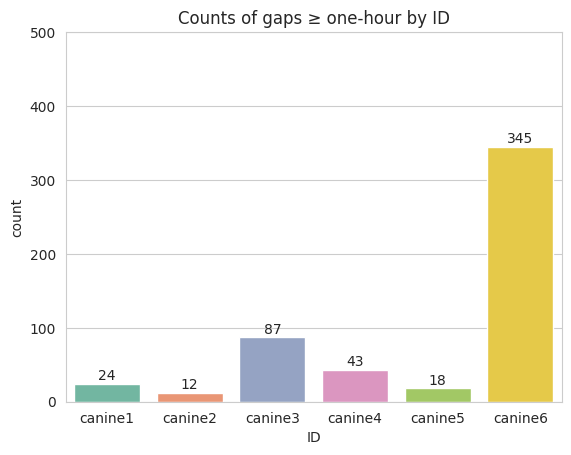

In [16]:
large_gap = gap_df[gap_df["gap_min"] >= 60].copy()
large_df = large_gap.groupby("ID").size().reset_index(name = "count")

ax = sns.barplot(
    data = large_df,
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
    )

for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
      )
plt.ylim(0, 500)
plt.title("Counts of gaps ≥ one-hour by ID")
plt.show()



In [17]:
# setting the max gap as one-hour
max_gap = 60

In [18]:
def add_split_flags(df, max_gap = max_gap):

  df = df.copy()

  df = df.sort_values(["ID", "timestamp"])

  # adding flags for making splits
  df["split_flag"] = (
      (df["gap_min"] >= max_gap) | (df["gap_min"].isna())
  )

  df["sub_id"] = (
      df
      .groupby("ID")["split_flag"]
      .cumsum()
      .astype(str)
      .str.zfill(3)
  )

  df["split_id"] = (
      df["ID"] + "-" + df["sub_id"]
  )

  # df = df.drop(columns = ["sub_id"])

  return df

In [19]:
gap_split = add_split_flags(gap_df, max_gap)

gap_split.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,001,canine1-001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,001,canine1-001
3039,canine2,2025-04-09 12:56:00,308.0,hyperglycemia,False,NaN,True,001,canine2-001
3040,canine2,2025-04-09 13:11:00,274.0,hyperglycemia,False,15.0,False,001,canine2-001


In [20]:
print(f"Number of groups: {gap_split["split_id"].nunique()}")

split_counts = gap_split.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")
display(split_counts.describe())

Number of groups: 535


,Observations
count,535.000000
mean,66.143925
std,119.464049
min,1.000000
25%,6.000000
50%,28.000000
75%,75.000000
max,945.000000


In [21]:
def remove_small_subgroup(df, split_threshold):

  """
  df: dataframe to split
  split_threshold: minimum duration in minutes for a subgroup to be valid
  """

  segments = (
      df
      .groupby("split_id", sort = False)["timestamp"]
      .agg(("count", "max", "min"))
  )

  # get duration and get ids with duration > split_threshold
  segments["duration"] = segments["max"] - segments["min"]
  segments["valid"] = segments["duration"] > pd.Timedelta(minutes = split_threshold)

  valid_ids = segments[segments["valid"] == True].index

  filtered_df = df[df["split_id"].isin(valid_ids)]
  final_segments = segments[segments["valid"] == True]

  return final_segments, filtered_df

In [22]:
# getting subgroups that have duration longer than four hours
split_threshold = 240

In [23]:
filter_segments, filtered_df = remove_small_subgroup(gap_split, split_threshold = split_threshold)
print(f"Number of observations after filtering: {filtered_df.shape[0]}")

Number of observations after filtering: 33542


## Summary of Duration

In [24]:
filter_segments["duration"].describe()

,duration
count,287
mean,0 days 22:49:33.658536585
std,1 days 02:43:36.554964079
min,0 days 04:01:00
25%,0 days 08:40:30
50%,0 days 14:11:00
75%,0 days 22:11:30
max,7 days 09:34:00


In [25]:
filtered_df.head(2)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,001,canine1-001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,001,canine1-001


In [26]:
filtered_split = filtered_df.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")

In [27]:
filtered_split.head(3)

,split_id,Observations
0,canine1-001,95
1,canine1-002,131
2,canine1-003,476


In [28]:
print(f"Number of subgroups after filtering: {filtered_split.shape[0]}")
display(filtered_split.describe())

Number of subgroups after filtering: 287


,Observations
count,287.00000
mean,116.87108
std,145.00972
min,16.00000
25%,39.00000
50%,68.00000
75%,120.00000
max,945.00000


In [29]:
cleaned_split = add_split_flags(filtered_df, max_gap)
display(cleaned_split.groupby("ID")["split_id"].nunique().reset_index(name = "Number of Subgroups"))
display(cleaned_split.groupby("ID")["split_id"].tail(1).reset_index(name = "Check the last subgroup"))
display(cleaned_split.groupby("split_id").head(2).head(6))

,ID,Number of Subgroups
0,canine1,21
1,canine2,8
2,canine3,46
3,canine4,18
4,canine5,18
5,canine6,176


,index,Check the last subgroup
0,3038,canine1-021
1,4027,canine2-008
2,10088,canine3-046
3,12537,canine4-018
4,18420,canine5-018
5,35386,canine6-176


,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,001,canine1-001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,001,canine1-001
95,canine1,2025-11-02 07:54:00,450.0,hyperglycemia,False,233.0,True,002,canine1-002
96,canine1,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0,False,002,canine1-002
226,canine1,2025-11-04 20:57:00,500.0,hyperglycemia,False,2726.0,True,003,canine1-003
227,canine1,2025-11-04 20:59:00,500.0,hyperglycemia,False,2.0,False,003,canine1-003


In [30]:
all_df = cleaned_split.sort_values(by=["ID", "sub_id", "timestamp"])

# recalculate gap_min
all_df["gap_min"] = (
    all_df
    .groupby("split_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

all_df.groupby("split_id").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine1,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,True,001,canine1-001
1,canine1,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,False,001,canine1-001
95,canine1,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN,True,002,canine1-002
96,canine1,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0,False,002,canine1-002


In [31]:
# now clean up the columns that we are not going to use and reassign IDs as split_ids
all_df["ID"] = all_df["split_id"]

all_df = all_df.drop(columns = ["split_id", "split_flag", "sub_id"])

all_df.groupby("ID").head(2).head(10)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
95,canine1-002,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN
96,canine1-002,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0
226,canine1-003,2025-11-04 20:57:00,500.0,hyperglycemia,False,NaN
227,canine1-003,2025-11-04 20:59:00,500.0,hyperglycemia,False,2.0
702,canine1-004,2025-11-09 01:59:00,237.0,normal,True,NaN
703,canine1-004,2025-11-09 02:14:00,245.0,normal,True,15.0
761,canine1-005,2025-11-09 16:54:00,259.0,hyperglycemia,False,NaN
762,canine1-005,2025-11-09 17:09:00,262.0,hyperglycemia,False,15.0


## DF without onset indicator

### .csv file that contains all dogs

In [168]:
# saving to .csv file in case you want to save the file in your directory for easier loading

# Ainsley
# out_dir =

# Ci
# out_dir =

# WooJung
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated"

all_df.to_csv(out_dir + "/all_df.csv", index = False)

print("all_df in .csv format saved in:", out_dir)

all_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated


### .csv file that has canine 1 as test and others as train for cross validation

1. combined dataset with "train_test" column that indicates the data set type

2. train / test set saved separately

🟡 combined set with "train_test" column

In [35]:
all_cv_df = all_df.copy()

all_cv_df["train_test"] = np.where(all_df["ID"].str.contains("canine1"), "test", "train")

display(all_cv_df.groupby("ID").head(2).head(2))
display(all_cv_df.groupby("ID").tail(2).tail(2))

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,train_test
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN,test
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0,test


,ID,timestamp,glucose,glucose_category,normal_range,gap_min,train_test
35385,canine6-176,2026-03-07 21:10:00,88.0,normal,True,1.0,train
35386,canine6-176,2026-03-07 21:21:00,108.0,normal,True,11.0,train


In [33]:
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated"

all_cv_df.to_csv(out_dir + "/all_cv_df.csv", index = False)

print("all_cv_df in .csv format saved in:", out_dir)

all_cv_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated


🟡 separate dataset

In [171]:
train_df = all_cv_df[all_cv_df["train_test"] == "train"].copy()
test_df = all_cv_df[all_cv_df["train_test"] == "test"].copy()

# drop column
train_df = train_df.drop(columns = ["train_test"])
test_df = test_df.drop(columns = ["train_test"])


display(train_df.head(2))
display(test_df.head(2))

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
3039,canine2-001,2025-04-09 12:56:00,308.0,hyperglycemia,False,NaN
3040,canine2-001,2025-04-09 13:11:00,274.0,hyperglycemia,False,15.0


,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0


In [172]:
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated"

train_df.to_csv(out_dir + "/cv_train_df.csv", index = False)

print("train_df in .csv format saved in:", out_dir)


out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated"

test_df.to_csv(out_dir + "/cv_test_df.csv", index = False)

print("test_df in .csv format saved in:", out_dir)

train_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
test_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
